# 4 · Few-Shot Prototypical Network — Anomaly Detection

## Motivation

Deep SVDD and FCDD both suffer from the **trivial solution**: the network can satisfy the one-class loss (all outputs → 0) without learning any crack-relevant features. This collapse is especially severe on SDNET2018 because:

1. Pretrained ResNet-18 already extracts good features — fine-tuning with a one-class loss gives very little gradient signal before collapse.
2. Centre initialisation from mean normal embeddings makes initial distances tiny, so the loss is near-zero before the first weight update.

**Prototypical Networks** sidestep this entirely by using a **discriminative objective** with both normal and anomaly examples during training, while remaining a one-class detector at test time.

## Inspiration
Our ProtoNet is an adapted prototype-based metric-learning model. It is grounded in Prototypical Networks for prototype construction and distance-based inference (Snell et al., 2017), while the embedding space is trained with triplet loss following the metric-learning formulation of FaceNet (Schroff et al., 2015). As related anomaly-detection work, Park et al. (2023) also show that prototype-guided triplet-style objectives can improve anomaly sensitivity, although their setting is weakly supervised video anomaly detection rather than image-based crack detection.

## Approach

| Stage | What happens |
|-------|-------------|
| **Meta-train** | Fine-tune encoder on (normal, crack) pairs with contrastive/triplet loss — embeddings of normals cluster, embeddings of cracks scatter |
| **Prototype** | Compute mean embedding of a small support set of normal images (5–10 images) |
| **Inference** | Anomaly score = L2 distance from query embedding to prototype |

No SVDD loss. No centre. No collapse possible — the loss requires both classes.

## Architecture

```
Frozen ResNet-18 (layer1, layer2)
       ↓  trainable layer3, layer4
  AdaptiveAvgPool2d
       ↓
  Projection Head  512 → 256 → 128
  (bias=False, no BN)
       ↓
  128-dim L2-normalised embedding
       ↓
  dist(z, prototype)  ← anomaly score
```

## Why L2 normalise here?

In Deep SVDD, L2 normalisation **broke** the radial distance. Here it is correct because we are using **cosine/angular distance on the unit sphere** not a hypersphere radius. The prototype and all queries live on the same sphere, so distance is purely directional.

In [ ]:
import sys, os, random
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from src.dataset import build_image_index, CrackDataset, save_splits, load_splits
from src.train_utils import eval_scores, calibrate_threshold, compute_metrics, print_metrics
from src.viz_utils import (
    plot_score_histogram, plot_roc_curve, plot_pr_curve,
    plot_confusion_matrix, plot_bar_ablation,
)


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


DATASET_DIR   = 'SDNET2018'
SPLITS_DIR    = 'splits'
CKPT_DIR      = 'checkpoints'
RESULTS_DIR   = 'results'
PREPROCESSING = 'clahe'

# Training
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
MAX_EPOCHS    = 40
PATIENCE      = 7
BATCH_SIZE    = 32    # pairs/triplets per batch
NUM_WORKERS   = 0

# Prototypical inference
N_SUPPORT     = 10    # normal images used to build prototype (held out from train)
EMB_DIM       = 128   # projection head output dimension

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device       : {DEVICE}')
print(f'Preprocessing: {PREPROCESSING}')
print(f'Support size : {N_SUPPORT} normal images')
print(f'Embedding dim: {EMB_DIM}')

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

Device       : cuda
Preprocessing: clahe
Support size : 10 normal images
Embedding dim: 128


## Data Loading

The training set here uses **all** images (normal + crack) because the triplet loss requires both classes. The `N_SUPPORT` normal images are held out from the training set and used only to build the prototype at inference time.

In [2]:
splits_exist = all(
    os.path.exists(os.path.join(SPLITS_DIR, f'patch_index_{s}.pkl'))
    for s in ('train', 'val', 'test')
)

if splits_exist:
    train_records, val_records, test_records = load_splits(SPLITS_DIR)
    print('Loaded existing splits.')
else:
    print('Splits not found — regenerating...')
    all_records  = build_image_index(DATASET_DIR)
    labels_all   = np.array([r['label'] for r in all_records])
    train_records, temp_records = train_test_split(
        all_records, test_size=0.30, stratify=labels_all, random_state=SEED)
    temp_labels = np.array([r['label'] for r in temp_records])
    val_records, test_records = train_test_split(
        temp_records, test_size=0.50, stratify=temp_labels, random_state=SEED)
    save_splits(train_records, val_records, test_records, SPLITS_DIR)

# ── Separate support set from training normals ─────────────────────────────
train_normal_idx = [i for i, r in enumerate(train_records) if r['label'] == 0]
rng = np.random.default_rng(SEED)
support_idx   = rng.choice(train_normal_idx, size=N_SUPPORT, replace=False).tolist()
support_set   = set(support_idx)
finetune_recs = [r for i, r in enumerate(train_records) if i not in support_set]
support_recs  = [train_records[i] for i in support_idx]

print(f'Train (all classes, excl. support): {len(finetune_recs):,}')
print(f'  → normal : {sum(r["label"]==0 for r in finetune_recs):,}')
print(f'  → crack  : {sum(r["label"]==1 for r in finetune_recs):,}')
print(f'Support set (normal only)         : {len(support_recs):,}')
print(f'Val                               : {len(val_records):,}')
print(f'Test                              : {len(test_records):,}')

Loaded existing splits.
Train (all classes, excl. support): 17,023
  → normal : 15,197
  → crack  : 1,826
Support set (normal only)         : 10
Val                               : 3,650
Test                              : 3,651


## TripletDataset

Each training sample is a **(anchor, positive, negative)** triplet:
- **anchor**: a normal image
- **positive**: a *different* normal image (same class → should be close)
- **negative**: a crack image (different class → should be far)

The dataset builds these on-the-fly so every epoch sees fresh triplets.

In [ ]:
class TripletDataset(Dataset):

    def __init__(self, records, preprocessing='clahe', n_per_epoch=None):
        self.normal_recs = [r for r in records if r['label'] == 0]
        self.crack_recs  = [r for r in records if r['label'] == 1]
        assert len(self.normal_recs) > 1, 'Need at least 2 normal images for triplets'
        assert len(self.crack_recs)  > 0, 'Need at least 1 crack image for triplets'

        self.preprocessing = preprocessing
        self.n_per_epoch   = n_per_epoch or len(self.normal_recs)

        # Pre-build CrackDataset objects for fast loading
        self._normal_ds = CrackDataset(self.normal_recs, preprocessing=preprocessing,
                                        augment=True)
        self._crack_ds  = CrackDataset(self.crack_recs,  preprocessing=preprocessing,
                                        augment=True)

    def __len__(self):
        return self.n_per_epoch

    def __getitem__(self, _):
        # Sample anchor index
        anc_idx = random.randint(0, len(self.normal_recs) - 1)
        # Sample positive — different from anchor
        pos_idx = random.randint(0, len(self.normal_recs) - 2)
        if pos_idx >= anc_idx:
            pos_idx += 1
        # Sample negative
        neg_idx = random.randint(0, len(self.crack_recs) - 1)

        anchor,   _ = self._normal_ds[anc_idx]
        positive, _ = self._normal_ds[pos_idx]
        negative, _ = self._crack_ds[neg_idx]

        return anchor, positive, negative


triplet_ds = TripletDataset(finetune_recs, preprocessing=PREPROCESSING,
                              n_per_epoch=len([r for r in finetune_recs if r['label']==0]))
triplet_loader = DataLoader(triplet_ds, batch_size=BATCH_SIZE,
                             shuffle=True, num_workers=NUM_WORKERS)

val_ds   = CrackDataset(val_records,  preprocessing=PREPROCESSING)
test_ds  = CrackDataset(test_records, preprocessing=PREPROCESSING)
val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Triplets per epoch : {len(triplet_ds):,}')
print(f'Batches per epoch  : {len(triplet_loader):,}')

Triplets per epoch : 15,197
Batches per epoch  : 475


## ProtoNet Model

The model is a **ResNet-18 encoder** (pretrained ImageNet) with a small **projection head** that maps the 512-dim pooled feature to a 128-dim L2-normalised embedding.

Key design choices:
- `bias=False` in all Linear layers — no bias shortcut (same reason as in fixed DeepSVDD)
- No BatchNorm in the head — keeps embedding geometry clean
- L2 normalisation at the **output** — correct here because we are measuring cosine distance between embeddings, not radial distance from a fixed centre
- Freeze `layer1` and `layer2` — lower layers detect textures already captured by ImageNet pretraining; only `layer3` and `layer4` are fine-tuned

In [ ]:
import torchvision.models as tvm


class ProtoNet(nn.Module):

    def __init__(
        self,
        emb_dim: int = 128,
        freeze_until: str = 'layer2',
        pretrained: bool = True,
    ):
        super().__init__()
        weights = tvm.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = tvm.resnet18(weights=weights)

        # Keep all layers up to (and including) layer4; remove avgpool + fc
        self.encoder = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4,
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        # Freeze requested layers
        freeze_map = {'layer1': 4, 'layer2': 5, 'layer3': 6}
        freeze_up_to = freeze_map.get(freeze_until, 5)
        for i, child in enumerate(self.encoder.children()):
            if i <= freeze_up_to:
                for p in child.parameters():
                    p.requires_grad = False

        # Projection head — bias=False everywhere
        self.head = nn.Sequential(
            nn.Linear(512, 256, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(256, emb_dim, bias=False),
        )

        self.emb_dim = emb_dim

        # Pre-declare prototype buffer so Pylance knows it's a Tensor, not callable
        self.register_buffer('prototype', torch.zeros(emb_dim))

    def embed(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.encoder(x).flatten(1)   # (B, 512)
        z     = self.head(feats)              # (B, emb_dim)
        return F.normalize(z, p=2, dim=1)    # unit sphere

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.embed(x)

    # ── Prototype management ───────────────────────────────────────────────

    def build_prototype(self, support_records, preprocessing, device):
        self.eval()
        sup_ds     = CrackDataset(support_records, preprocessing=preprocessing)
        sup_loader = DataLoader(sup_ds, batch_size=len(sup_ds), shuffle=False)
        with torch.no_grad():
            imgs, _ = next(iter(sup_loader))
            embs = self.embed(imgs.to(device))          # (N_support, emb_dim)
        self.prototype = embs.mean(dim=0)               # (emb_dim,)
        return self.prototype

    def anomaly_score(self, x: torch.Tensor) -> torch.Tensor:
        z = self.embed(x)
        return torch.norm(z - self.prototype.unsqueeze(0), p=2, dim=1)



model_proto = ProtoNet(emb_dim=EMB_DIM, freeze_until='layer2').to(DEVICE)

n_total     = sum(p.numel() for p in model_proto.parameters())
n_trainable = sum(p.numel() for p in model_proto.parameters() if p.requires_grad)
print(f'Total params     : {n_total:,}')
print(f'Trainable params : {n_trainable:,}  ({100*n_trainable/n_total:.1f}%)')

# Quick forward pass sanity check
x_dummy = torch.randn(4, 3, 256, 256).to(DEVICE)
with torch.no_grad():
    z_dummy = model_proto.embed(x_dummy)
print(f'Embedding shape  : {z_dummy.shape}   (should be [4, {EMB_DIM}])')
print(f'Embedding norms  : {z_dummy.norm(dim=1).tolist()}   (should all be ~1.0)')

Total params     : 11,340,352
Trainable params : 10,657,280  (94.0%)
Embedding shape  : torch.Size([4, 128])   (should be [4, 128])
Embedding norms  : [1.0, 1.0, 0.9999999403953552, 0.9999999403953552]   (should all be ~1.0)


## Triplet Loss & Training Loop

### Triplet loss

$$\mathcal{L}_{triplet} = \frac{1}{N} \sum_{i=1}^{N} \max\!\left(0,\; d(a_i, p_i) - d(a_i, n_i) + \alpha\right)$$

where:
- $a$ = anchor (normal), $p$ = positive (normal), $n$ = negative (crack)
- $d(u, v) = \|u - v\|_2$ — Euclidean distance on the unit sphere
- $\alpha = 0.5$ — margin that forces crack embeddings to be at least 0.5 units further from the anchor than the positive normal

The loss is non-zero only when the current batch does not satisfy the margin — this gives an informative gradient signal from the first epoch, unlike SVDD where the gradient collapses as soon as the network finds the trivial solution.

In [ ]:
MARGIN = 0.5   # triplet margin — embeddings on unit sphere so max dist ≈ 2.0


def train_proto_epoch(
    model: ProtoNet,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    margin: float = MARGIN,
) -> tuple[float, float]:
    
    model.train()
    total_loss   = 0.0
    total_active = 0
    total_count  = 0

    for anchor, positive, negative in loader:
        anchor   = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        z_a = model.embed(anchor)
        z_p = model.embed(positive)
        z_n = model.embed(negative)

        d_ap = torch.norm(z_a - z_p, p=2, dim=1)  # anchor–positive distance
        d_an = torch.norm(z_a - z_n, p=2, dim=1)  # anchor–negative distance

        triplet_losses = F.relu(d_ap - d_an + margin)
        loss = triplet_losses.mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss   += loss.item()
        total_active += (triplet_losses > 0).sum().item()
        total_count  += len(anchor)

    return total_loss / len(loader), total_active / total_count


class EarlyStopping:
    
    def __init__(self, patience: int, ckpt_path: str, min_delta: float = 1e-4):
        self.patience   = patience
        self.ckpt_path  = ckpt_path
        self.min_delta  = min_delta
        self.best_auroc = -1.0
        self.counter    = 0

    def step(self, auroc: float, model: nn.Module, extra: dict = None) -> bool:
        if auroc > self.best_auroc + self.min_delta:
            self.best_auroc = auroc
            self.counter    = 0
            payload = {'model_state': model.state_dict()}
            if extra:
                payload.update(extra)
            torch.save(payload, self.ckpt_path)
        else:
            self.counter += 1
        return self.counter >= self.patience

    def summary(self) -> str:
        return f'Best val AUROC: {self.best_auroc:.4f}'


print('train_proto_epoch and EarlyStopping defined.')

train_proto_epoch and EarlyStopping defined.


## Training

In [ ]:
def eval_proto_scores(model: ProtoNet, loader: DataLoader, device: torch.device):
    
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            s = model.anomaly_score(x)   # (B,)
            all_scores.append(s.cpu().numpy())
            all_labels.append(y.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)



optimizer_proto = optim.Adam(
    filter(lambda p: p.requires_grad, model_proto.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)
scheduler_proto = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_proto, T_max=MAX_EPOCHS, eta_min=1e-6,
)

es_proto = EarlyStopping(
    patience  = PATIENCE,
    ckpt_path = os.path.join(CKPT_DIR, 'proto_best.pt'),
)

train_losses_proto = []
active_fracs_proto = []
val_aurocs_proto   = []

print(f'Training ProtoNet (max {MAX_EPOCHS} epochs, patience={PATIENCE}, margin={MARGIN})...\n')
for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, frac_active = train_proto_epoch(
        model_proto, triplet_loader, optimizer_proto, DEVICE)
    train_losses_proto.append(tr_loss)
    active_fracs_proto.append(frac_active)
    scheduler_proto.step()

    # Rebuild prototype from support set each epoch (embeddings have changed)
    model_proto.build_prototype(support_recs, PREPROCESSING, DEVICE)

    val_scores, val_labels_e = eval_proto_scores(model_proto, val_loader, DEVICE)
    val_auroc = float(roc_auc_score(val_labels_e, val_scores))
    val_aurocs_proto.append(val_auroc)

    marker = ' *' if val_auroc >= es_proto.best_auroc else ''
    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f'  Epoch {epoch:3d}  loss={tr_loss:.4f}  '
              f'active={frac_active:.2%}  val_AUROC={val_auroc:.4f}{marker}')

    stop = es_proto.step(val_auroc, model_proto,
                         extra={'train_losses': train_losses_proto,
                                'val_aurocs':   val_aurocs_proto})
    if stop:
        print(f'  Early stop at epoch {epoch}.')
        break

print()
print(es_proto.summary())

Training ProtoNet (max 40 epochs, patience=7, margin=0.5)...

  Epoch   1  loss=0.0269  active=10.13%  val_AUROC=0.7872 *
  Epoch   5  loss=0.0064  active=2.60%  val_AUROC=0.7408
  Early stop at epoch 8.

Best val AUROC: 0.7872


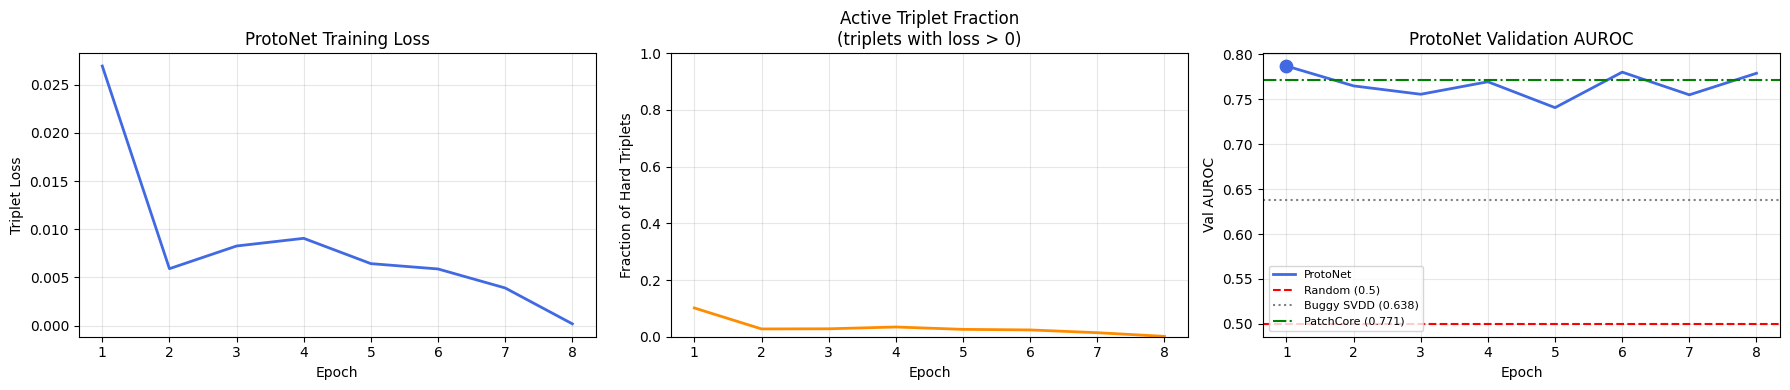

Best val AUROC: 0.7872 (epoch 1)


In [ ]:
SVDD_BEST_AUROC  = 0.638   
PATCHCORE_AUROC  = 0.7714

epochs_p = range(1, len(train_losses_proto) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss
axes[0].plot(epochs_p, train_losses_proto, color='royalblue', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Triplet Loss')
axes[0].set_title('ProtoNet Training Loss'); axes[0].grid(alpha=0.3)

# Active fraction
axes[1].plot(epochs_p, active_fracs_proto, color='darkorange', lw=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Fraction of Hard Triplets')
axes[1].set_title('Active Triplet Fraction\n(triplets with loss > 0)')
axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3)

# Val AUROC
axes[2].plot(epochs_p, val_aurocs_proto, color='royalblue', lw=2, label='ProtoNet')
axes[2].axhline(0.5,              color='red',  linestyle='--', lw=1.5, label='Random (0.5)')
axes[2].axhline(SVDD_BEST_AUROC,  color='grey', linestyle=':',  lw=1.5,
                label=f'Buggy SVDD ({SVDD_BEST_AUROC:.3f})')
axes[2].axhline(PATCHCORE_AUROC,  color='green', linestyle='-.', lw=1.5,
                label=f'PatchCore ({PATCHCORE_AUROC:.3f})')
best_e = int(np.argmax(val_aurocs_proto))
axes[2].scatter(best_e + 1, val_aurocs_proto[best_e], s=80, color='royalblue', zorder=5)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Val AUROC')
axes[2].set_title('ProtoNet Validation AUROC')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'proto_training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Best val AUROC: {max(val_aurocs_proto):.4f} (epoch {best_e+1})')

## Cell 8 — Test Set Evaluation

Load the best checkpoint, rebuild the prototype from the support set, then evaluate on the held-out test set.

In [9]:
import pickle

# Load best weights
ckpt = torch.load(os.path.join(CKPT_DIR, 'proto_best.pt'),
                   map_location=DEVICE, weights_only=True)
model_proto.load_state_dict(ckpt['model_state'])

# Rebuild prototype with best weights
model_proto.build_prototype(support_recs, PREPROCESSING, DEVICE)
print(f'Prototype norm: {model_proto.prototype.norm().item():.4f}  (should be close to 1.0 — unit sphere)')

# Calibrate threshold on validation set
val_scores, val_labels = eval_proto_scores(model_proto, val_loader, DEVICE)
tau, val_f1 = calibrate_threshold(val_scores, val_labels)
print(f'Threshold τ = {tau:.4f}  (val F1 = {val_f1:.4f})')

# Test evaluation
test_scores, test_labels = eval_proto_scores(model_proto, test_loader, DEVICE)
metrics_proto = compute_metrics(test_scores, test_labels, tau)

print()
print('=== ProtoNet Test Results ===')
print_metrics(metrics_proto, 'ProtoNet')

# Save results
with open(os.path.join(RESULTS_DIR, 'results_proto.pkl'), 'wb') as f:
    pickle.dump({
        'scores': test_scores, 'labels': test_labels,
        'threshold': tau, 'val_f1': val_f1,
        **{k: v for k, v in metrics_proto.items() if k != 'preds'},
    }, f)
print('Results saved.')

Prototype norm: 0.9993  (should be close to 1.0 — unit sphere)
Threshold τ = 0.1365  (val F1 = 0.5410)

=== ProtoNet Test Results ===
[ProtoNet] AUROC: 0.7673  AUPRC: 0.4876  F1: 0.5131
  Confusion matrix:
    TN=  3170  FP=    90
    FN=   225  TP=   166
Results saved.


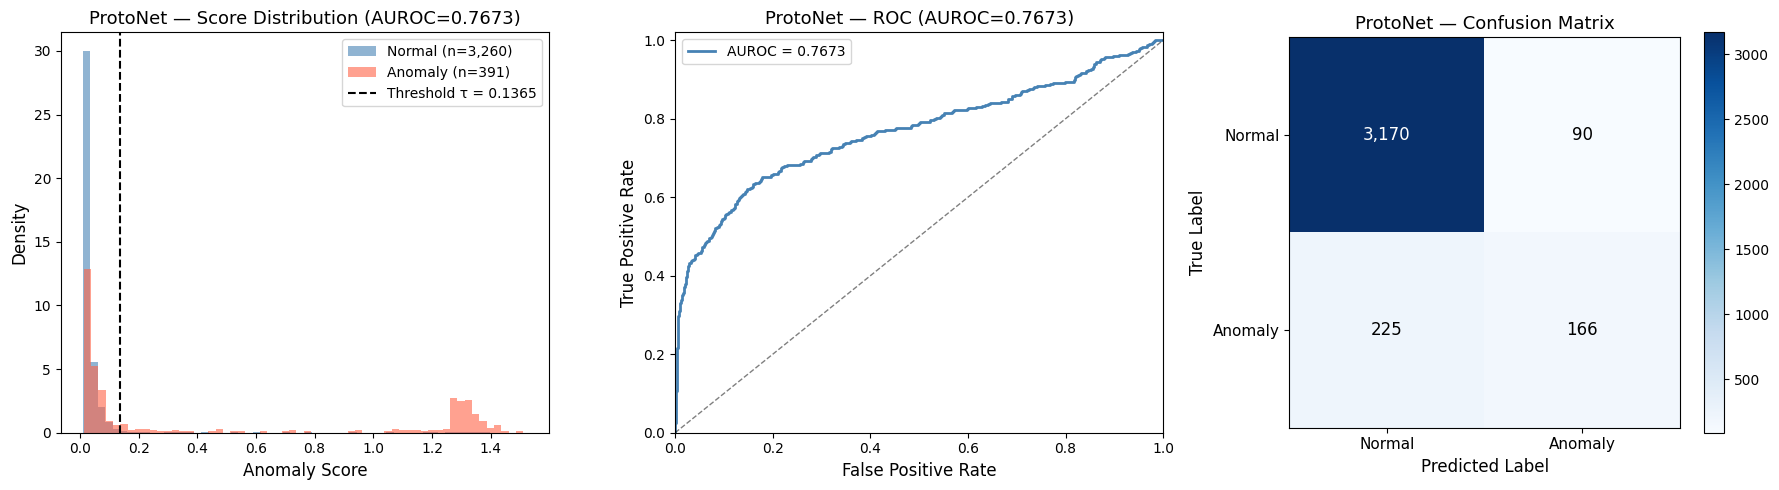

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_score_histogram(
    test_scores, test_labels, threshold=tau,
    title=f'ProtoNet — Score Distribution (AUROC={metrics_proto["auroc"]:.4f})',
    ax=axes[0],
)
plot_roc_curve(
    test_scores, test_labels,
    auroc=metrics_proto['auroc'],
    title=f'ProtoNet — ROC (AUROC={metrics_proto["auroc"]:.4f})',
    ax=axes[1],
)
plot_confusion_matrix(
    metrics_proto['cm'],
    title='ProtoNet — Confusion Matrix',
    ax=axes[2],
)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'proto_test_metrics.png'), dpi=120, bbox_inches='tight')
plt.show()

In [11]:
from sklearn.manifold import TSNE

# Extract all test embeddings
model_proto.eval()
all_embs, all_lbls = [], []
with torch.no_grad():
    for x, y in test_loader:
        z = model_proto.embed(x.to(DEVICE))
        all_embs.append(z.cpu().numpy())
        all_lbls.append(y.numpy())

embs_np  = np.concatenate(all_embs)   # (N_test, emb_dim)
lbls_np  = np.concatenate(all_lbls)   # (N_test,)

# Also add prototype as a special point
proto_np = model_proto.prototype.cpu().numpy()[None]   # (1, emb_dim)
all_pts  = np.concatenate([embs_np, proto_np], axis=0)

print(f'Running t-SNE on {len(embs_np):,} test embeddings + 1 prototype...')
tsne     = TSNE(n_components=2, perplexity=40, random_state=SEED, n_iter=1000)
coords   = tsne.fit_transform(all_pts)

emb_coords   = coords[:-1]
proto_coords = coords[-1]

fig, ax = plt.subplots(figsize=(9, 7))
colors = {0: '#2196F3', 1: '#F44336'}
names  = {0: 'Normal', 1: 'Crack'}
for lbl in [0, 1]:
    mask = lbls_np == lbl
    ax.scatter(emb_coords[mask, 0], emb_coords[mask, 1],
               c=colors[lbl], label=names[lbl], s=10, alpha=0.5)

# Mark prototype
ax.scatter(*proto_coords, marker='*', s=300, c='black', zorder=10, label='Prototype')
ax.set_title(f'ProtoNet — t-SNE of Test Embeddings\n(AUROC={metrics_proto["auroc"]:.4f})',
             fontsize=13)
ax.legend(fontsize=10); ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'proto_tsne.png'), dpi=120, bbox_inches='tight')
plt.show()

Running t-SNE on 3,651 test embeddings + 1 prototype...


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## Ablation: Support Set Size

One unique property of the prototypical approach is that the support set size `N_SUPPORT` is a hyperparameter that can be tuned **without retraining** — we just recompute the prototype from a different number of normal images.

This cell sweeps `N_SUPPORT` from 1 to 50 and plots how val AUROC changes.

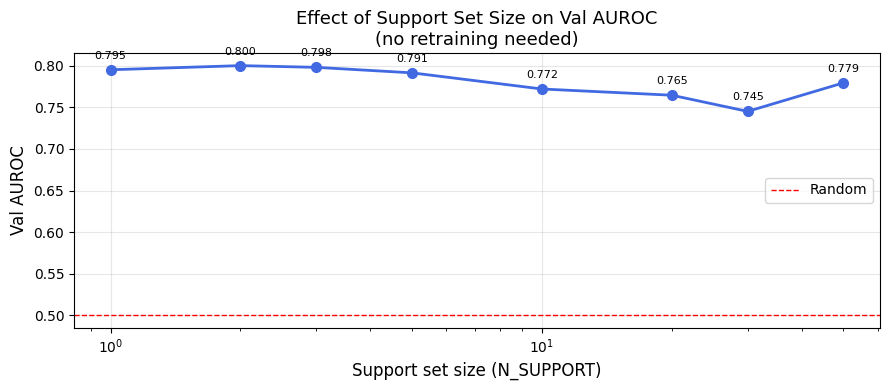

In [12]:
support_sizes  = [1, 2, 3, 5, 10, 20, 30, 50]
aurocs_by_size = []

# Pool of available normal images from training set (all, including support_recs)
all_train_normals = [r for r in train_records if r['label'] == 0]
rng2 = np.random.default_rng(SEED + 1)

model_proto.eval()
for k in support_sizes:
    if k > len(all_train_normals):
        aurocs_by_size.append(None)
        continue
    k_recs = rng2.choice(all_train_normals, size=k, replace=False).tolist()
    model_proto.build_prototype(k_recs, PREPROCESSING, DEVICE)
    vs, vl = eval_proto_scores(model_proto, val_loader, DEVICE)
    aurocs_by_size.append(roc_auc_score(vl, vs))

# Restore original prototype
model_proto.build_prototype(support_recs, PREPROCESSING, DEVICE)

fig, ax = plt.subplots(figsize=(9, 4))
valid = [(k, a) for k, a in zip(support_sizes, aurocs_by_size) if a is not None]
xs, ys = zip(*valid)
ax.plot(xs, ys, 'o-', color='royalblue', lw=2, markersize=7)
for x, y in zip(xs, ys):
    ax.annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax.axhline(0.5, color='red', linestyle='--', lw=1, label='Random')
ax.set_xlabel('Support set size (N_SUPPORT)', fontsize=12)
ax.set_ylabel('Val AUROC', fontsize=12)
ax.set_title('Effect of Support Set Size on Val AUROC\n(no retraining needed)', fontsize=13)
ax.set_xscale('log')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'proto_support_ablation.png'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
model_proto_r = ProtoNet(emb_dim=EMB_DIM, freeze_until='layer2', pretrained=False).to(DEVICE)
ckpt_r = torch.load(os.path.join(CKPT_DIR, 'proto_best.pt'),
                     map_location=DEVICE, weights_only=True)
# strict=False: checkpoint contains 'prototype' buffer saved during training,
# which is a plain tensor attribute after build_prototype() reassigns it.
model_proto_r.load_state_dict(ckpt_r['model_state'], strict=False)
model_proto_r.build_prototype(support_recs, PREPROCESSING, DEVICE)

test_scores_r, test_labels_r = eval_proto_scores(model_proto_r, test_loader, DEVICE)
metrics_r = compute_metrics(test_scores_r, test_labels_r, tau)

print('=== Reload verification ===')
print_metrics(metrics_r, 'ProtoNet (reloaded)')
match = abs(metrics_r['auroc'] - metrics_proto['auroc']) < 1e-6
print(f'AUROC matches original: {match}')

## Results
ProtoNet achieved 0.7673 AUROC and 0.4876 AUPRC, with 3170 TN, 90 FP, 225 FN, and 166 TP. Its AUROC is comparable to PatchCore (0.7744), but its error profile is much better for practical use. In particular, ProtoNet has far higher precision: AUPRC is nearly 2× higher than PatchCore (0.4876 vs 0.2656), and false positives are dramatically lower (90 vs 682). This means ProtoNet’s anomaly scores are much more reliable, making it more suitable for real inspection settings where false alarms are costly.

## Issues
ProtoNet’s main weakness is recall. It detects fewer cracks than PatchCore (166 TP vs 248) and misses more positives (225 FN), suggesting that some subtle crack patches still remain too close to the normal prototype in embedding space. Although triplet loss makes the embedding more discriminative than a purely normal-only method, the model also overfits quickly, with validation AUROC peaking very early. In short, ProtoNet uses crack supervision to improve precision strongly, but does not yet convert that supervision into equally strong recall.

> See notebook 9_protonet_ablation.ipynb for ablation to improve the model